In [12]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [13]:
PROJECT_ROOT = Path("..")

CLINICAL_PATH = (
    PROJECT_ROOT /
    "data" /
    "clinical" /
    "anemia.csv"
)

clinical_df = pd.read_csv(CLINICAL_PATH)

clinical_df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [14]:
print("="*60)
print("Clinical Dataset Information")
print("="*60)

clinical_df.info()

print("\n")

print(clinical_df.describe())

Clinical Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


            Gender   Hemoglobin          MCH         MCHC          MCV  \
count  1421.000000  1421.000000  1421.000000  1421.000000  1421.000000   
mean      0.520760    13.412738    22.905630    30.251232    85.523786   
std       0.499745     1.974546     3.969375     1.400898     9.636701   
min       0.000000     6.600000    16.000000    27.800000    69.400000   
25%       0.000000    11.700000    19.400000    29.000000    77.300000   
50%       1.000000    13.200000    22.70

In [15]:
missing = clinical_df.isnull().sum()

missing

Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64

In [16]:
duplicates = clinical_df.duplicated()

print("Duplicate Rows :", duplicates.sum())

clinical_df[duplicates].head(10)

Duplicate Rows : 887


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
237,1,14.9,22.7,29.1,83.7,0
238,0,15.9,25.4,28.3,72.0,0
240,0,14.9,16.0,31.4,87.5,0
242,0,11.6,22.3,30.9,74.5,1
243,1,12.7,19.5,28.9,82.9,1
244,1,12.7,28.5,28.2,92.3,1
245,0,14.1,29.7,30.5,75.2,0
246,1,14.9,25.8,31.3,82.9,0
249,0,13.4,25.2,30.2,95.9,0
250,0,14.7,28.9,31.0,69.8,0


In [17]:
clinical_df["Result"].value_counts()

Result
0    801
1    620
Name: count, dtype: int64

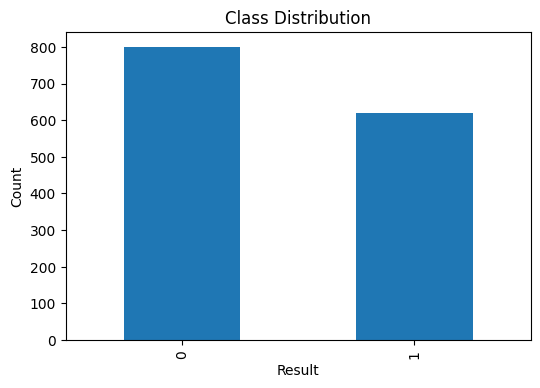

In [18]:
clinical_df["Result"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Class Distribution")

plt.xlabel("Result")

plt.ylabel("Count")

plt.show()

In [19]:
X = clinical_df.drop(
    columns=["Result"]
)

y = clinical_df["Result"]

print(X.shape)

print(y.shape)

(1421, 5)
(1421,)


In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.95930718,  0.75348274, -0.05182232, -0.82207061, -0.18932081],
       [-1.04241896,  1.26010665,  0.62862494, -1.39333406, -1.40385665],
       [-1.04241896, -2.23559834, -0.35424332, -0.46503096, -1.48690183],
       [-1.04241896,  0.75348274, -1.7403396 ,  0.8203118 ,  0.20514381],
       [ 0.95930718,  0.65215796, -0.22823457, -1.46474199,  1.45082159]])

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [22]:
print("Training :", X_train.shape)

print("Validation :", X_val.shape)

print("Testing :", X_test.shape)

Training : (994, 5)
Validation : (213, 5)
Testing : (214, 5)


In [23]:
processed_dir = PROJECT_ROOT / "data" / "processed"

processed_dir.mkdir(exist_ok=True)

In [24]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(994, 5)
(213, 5)
(214, 5)
(994,)
(213,)
(214,)


In [25]:
print(processed_dir)
print(processed_dir.exists())

..\data\processed
True


In [26]:
import os

print(os.listdir(processed_dir))

[]


In [27]:
import numpy as np

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

np.save(processed_dir / "X_train.npy", X_train)
np.save(processed_dir / "X_val.npy", X_val)
np.save(processed_dir / "X_test.npy", X_test)

np.save(processed_dir / "y_train.npy", y_train)
np.save(processed_dir / "y_val.npy", y_val)
np.save(processed_dir / "y_test.npy", y_test)

print("Files saved successfully!")

print("\nFiles in folder:")
print(os.listdir(processed_dir))

Files saved successfully!

Files in folder:
['X_test.npy', 'X_train.npy', 'X_val.npy', 'y_test.npy', 'y_train.npy', 'y_val.npy']
